<a href="https://colab.research.google.com/github/dgarciav27/LLM-basics/blob/main/finetuning_moscas_reales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning con fotos reales de trampas + evaluacion de conteo

Objetivo: el modelo ya aprendio a diferenciar especies con el dataset sintetico.
Esta segunda etapa NO busca mejorar la clasificacion por especie (no se puede
verificar la especie real en fotos bajadas de internet) — busca adaptar el
modelo al dominio real (trampas de verdad, luz real, fondo real) para que el
**conteo de moscas** sea confiable. La metrica que de verdad importa aqui es:
`moscas contadas por el modelo` vs `moscas contadas por ti a ojo` en fotos reales.

Pasos: instalar -> subir dataset sintetico -> subir best.pt -> descargar fotos
reales -> revisar manualmente -> auto-etiquetar -> split -> fine-tuning ->
evaluar conteo real.

## 1. Instalar dependencias

In [1]:
!pip install -q -U ultralytics icrawler opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00


## 2. Subir tu dataset sintetico
Comprime `C:\Users\User\Pictures\dataset-moscas\synthetic` en un .zip antes de subirlo
(clic derecho > Comprimir en Windows). Sube ese .zip aqui.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import zipfile, shutil

# ajusta esta ruta a donde este tu dataset en Drive
RUTA_EN_DRIVE = Path("/content/drive/MyDrive/moscas/synthetic")  # si subiste la carpeta ya descomprimida
# o, si subiste un .zip:
# RUTA_ZIP_DRIVE = Path("/content/drive/MyDrive/synthetic.zip")

SYN_DIR = Path("/content/dataset-moscas/synthetic")
SYN_DIR.mkdir(parents=True, exist_ok=True)

if RUTA_EN_DRIVE.is_dir():
    # copia directa, sin necesidad de descomprimir
    shutil.copytree(RUTA_EN_DRIVE, SYN_DIR, dirs_exist_ok=True)
else:
    # si en cambio subiste un .zip
    with zipfile.ZipFile(RUTA_ZIP_DRIVE, "r") as z:
        z.extractall(SYN_DIR)

print("Contenido de SYN_DIR:", list(SYN_DIR.iterdir()))
assert (SYN_DIR / "data.yaml").exists(), "No se encontro data.yaml, revisa la ruta"
print((SYN_DIR / "data.yaml").read_text())

Contenido de SYN_DIR: [PosixPath('/content/dataset-moscas/synthetic/data.yaml'), PosixPath('/content/dataset-moscas/synthetic/labels'), PosixPath('/content/dataset-moscas/synthetic/val'), PosixPath('/content/dataset-moscas/synthetic/images'), PosixPath('/content/dataset-moscas/synthetic/train')]
path: C:\Users\User\Pictures\dataset-moscas\synthetic
train: train/images
val: val/images

nc: 5
names: ['Muscidae', 'Calliphoridae', 'Sarcophagidae', 'Drosophilidae', 'Stratiomyidae']



In [ ]:
from google.colab import files
import zipfile, shutil
from pathlib import Path

print("Selecciona el .zip de tu carpeta synthetic:")
subido = files.upload()
zip_name = list(subido.keys())[0]

SYN_DIR = Path("/content/dataset-moscas/synthetic")
SYN_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(SYN_DIR)

# si el zip trae una subcarpeta extra (ej. synthetic/synthetic/...), aplanala
subcarpetas = [p for p in SYN_DIR.iterdir() if p.is_dir()]
if len(subcarpetas) == 1 and (subcarpetas[0] / "data.yaml").exists():
    interior = subcarpetas[0]
    for item in interior.iterdir():
        shutil.move(str(item), str(SYN_DIR / item.name))
    interior.rmdir()

print("Contenido de SYN_DIR:", list(SYN_DIR.iterdir()))
assert (SYN_DIR / "data.yaml").exists(), "No se encontro data.yaml, revisa la estructura del zip"
print("\ndata.yaml:")
print((SYN_DIR / "data.yaml").read_text())

## 3. Entrenar el modelo desde cero con tu dataset sintetico
No tienes `best.pt` todavia, asi que este paso entrena en Colab (usa GPU:
Entorno de ejecucion > Cambiar tipo de entorno > GPU). Es el mismo
entrenamiento del notebook original (`yolo26n-seg.pt`, 60 epocas) — despues
de esto SI vas a tener un `best.pt` para usar como auto-labeler y como punto
de partida del fine-tuning.

In [8]:
from pathlib import Path

SYN_DIR = Path("/content/dataset-moscas/synthetic")
data_yaml_path = SYN_DIR / "data.yaml"

contenido = data_yaml_path.read_text()
print("--- data.yaml original ---")
print(contenido)

lineas = contenido.splitlines()
lineas_nuevas = []
for linea in lineas:
    if linea.strip().startswith("path:"):
        lineas_nuevas.append(f"path: {SYN_DIR.resolve()}")
    else:
        lineas_nuevas.append(linea)

data_yaml_path.write_text("\n".join(lineas_nuevas) + "\n")

print("\n--- data.yaml corregido ---")
print(data_yaml_path.read_text())

--- data.yaml original ---
path: /content/dataset-moscas/synthetic
train: train/images
val: val/images

nc: 5
names: ['Muscidae', 'Calliphoridae', 'Sarcophagidae', 'Drosophilidae', 'Stratiomyidae']


--- data.yaml corregido ---
path: /content/dataset-moscas/synthetic
train: train/images
val: val/images

nc: 5
names: ['Muscidae', 'Calliphoridae', 'Sarcophagidae', 'Drosophilidae', 'Stratiomyidae']



In [9]:
from ultralytics import YOLO

CLASS_NAMES = ["Muscidae", "Calliphoridae", "Sarcophagidae", "Drosophilidae", "Stratiomyidae"]

model = YOLO("yolo26n-seg.pt")  # segmentacion, preentrenado, nano
resultados_sintetico = model.train(
    task="segment",
    data=("/content/dataset-moscas/synthetic/data.yaml"),
    epochs=60,
    imgsz=640,
    batch=16,
    name="moscas_piloto_seg",
)

BEST_WEIGHTS_SINTETICO = str(resultados_sintetico.save_dir / "weights" / "best.pt")
print("Modelo entrenado, pesos en:", BEST_WEIGHTS_SINTETICO)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset-moscas/synthetic/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=moscas_piloto_seg-4, nbs=64, nms=Fa

## 4. Descargar fotos reales de trampas (internet)
Queries genericas — no vas a poder confirmar la especie exacta en estas fotos,
por eso el objetivo de esta etapa es adaptacion de dominio para conteo, no
verificar clasificacion por especie.

In [10]:
from icrawler.builtin import BingImageCrawler
from pathlib import Path

QUERIES_TRAMPAS_REALES = [
    "yellow sticky trap flies close up",
    "trampa cromotropica amarilla moscas",
    "yellow sticky trap greenhouse insects",
    "fly trap yellow card pest monitoring",
]

RAW_TRAMPAS_DIR = Path("/content/trampas_reales_raw")
RAW_TRAMPAS_DIR.mkdir(exist_ok=True)

for i, query in enumerate(QUERIES_TRAMPAS_REALES):
    carpeta = RAW_TRAMPAS_DIR / f"query_{i}"
    carpeta.mkdir(exist_ok=True)
    crawler = BingImageCrawler(storage={"root_dir": str(carpeta)}, log_level=50)
    crawler.crawl(keyword=query, max_num=25)
    print(f"OK: '{query}' -> {carpeta}")

ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/022/650/362/non_2x/luxury-marble-texture-background-grey-gold-natural-stone-material-pattern-generative-ai-photo.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/033/292/882/non_2x/marble-granite-white-with-gold-texture-background-wall-surface-black-pattern-graphic-abstract-light-elegant-gray-floor-ceramic-counter-texture-stone-slab-smooth-tile-silver-natural-ai-generative-photo.jpg


OK: 'yellow sticky trap flies close up' -> /content/trampas_reales_raw/query_0


ERROR:downloader:Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/bbad47c7-f38d-4802-a9ff-a61c7d2b66a0/dfqdots-91c024f8-f2aa-4bb1-a912-ce1ed2dc703a.jpg
ERROR:downloader:Response status code 202, file https://cdn3.vectorstock.com/i/1000x1000/81/12/yin-yang-mandala-color-design-vector-29318112.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/005/412/079/original/instragram-frame-template-with-light-and-dark-theme-square-instagram-post-template-instagram-screen-social-network-mockup-free-vector.jpg


OK: 'trampa cromotropica amarilla moscas' -> /content/trampas_reales_raw/query_1
requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 257ms
Prepared 1 package in 59ms
Installed 1 package in 2ms
 + pi-heif==1.4.0

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

OK: 'yellow sticky trap greenhouse insects' -> /content/trampas_reales_raw/query_2


ERROR:downloader:Response status code 403, file https://www.therange.co.uk/media/1/8/1663855437_2742.jpg


OK: 'fly trap yellow card pest monitoring' -> /content/trampas_reales_raw/query_3


**Importante — revisa manualmente antes de seguir:**
Entra a `/content/trampas_reales_raw/query_*/` (panel de archivos a la izquierda)
y borra: ilustraciones/dibujos, trampas de mosca blanca/trips (van a salir
muchas y no son tus especies), fotos con watermark grande, fotos de producto
(Amazon/eBay). Con 4 queries x 25 probablemente te queden 20-40 fotos utiles,
que es lo que necesitas.

## 5. Aplanar las carpetas `query_*` en una sola carpeta de imagenes reales

In [11]:
import shutil

REAL_DIR = Path("/content/trampas_reales")
REAL_DIR.mkdir(exist_ok=True)

contador = 0
for carpeta_query in sorted(RAW_TRAMPAS_DIR.glob("query_*")):
    for img_path in carpeta_query.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".webp"]:
            continue
        destino = REAL_DIR / f"real_{contador:03d}{img_path.suffix.lower()}"
        shutil.copy(img_path, destino)
        contador += 1

print(f"{contador} fotos reales copiadas a {REAL_DIR}")

90 fotos reales copiadas a /content/trampas_reales


## 6. Auto-etiquetar con el modelo entrenado en sintetico
El modelo predice clase + poligono directo (ya es un modelo de segmentacion).
La clase predicha es la mejor estimacion disponible, pero recuerda: no se
puede verificar contra la especie real en estas fotos de internet.

In [12]:
from ultralytics import YOLO

modelo_auto = YOLO(BEST_WEIGHTS_SINTETICO)

LABELS_REAL_DIR = Path("/content/trampas_reales_labels")
LABELS_REAL_DIR.mkdir(exist_ok=True)

def auto_labelizar(carpeta_imgs, carpeta_labels, conf=0.3):
    n_con_deteccion = 0
    for img_path in carpeta_imgs.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        res = modelo_auto.predict(str(img_path), conf=conf, verbose=False)[0]
        lineas = []
        if res.masks is not None:
            for poly, cls_id in zip(res.masks.xyn, res.boxes.cls.cpu().numpy().astype(int)):
                puntos = " ".join(f"{x:.5f} {y:.5f}" for x, y in poly)
                lineas.append(f"{cls_id} {puntos}")
            if lineas:
                n_con_deteccion += 1
        (carpeta_labels / (img_path.stem + ".txt")).write_text("\n".join(lineas))
    print(f"Auto-labels generados en {carpeta_labels} ({n_con_deteccion} fotos con al menos 1 deteccion)")

auto_labelizar(REAL_DIR, LABELS_REAL_DIR, conf=0.3)

Auto-labels generados en /content/trampas_reales_labels (73 fotos con al menos 1 deteccion)


## 7. Revision visual rapida (pesca los malos antes de meterlos al dataset)

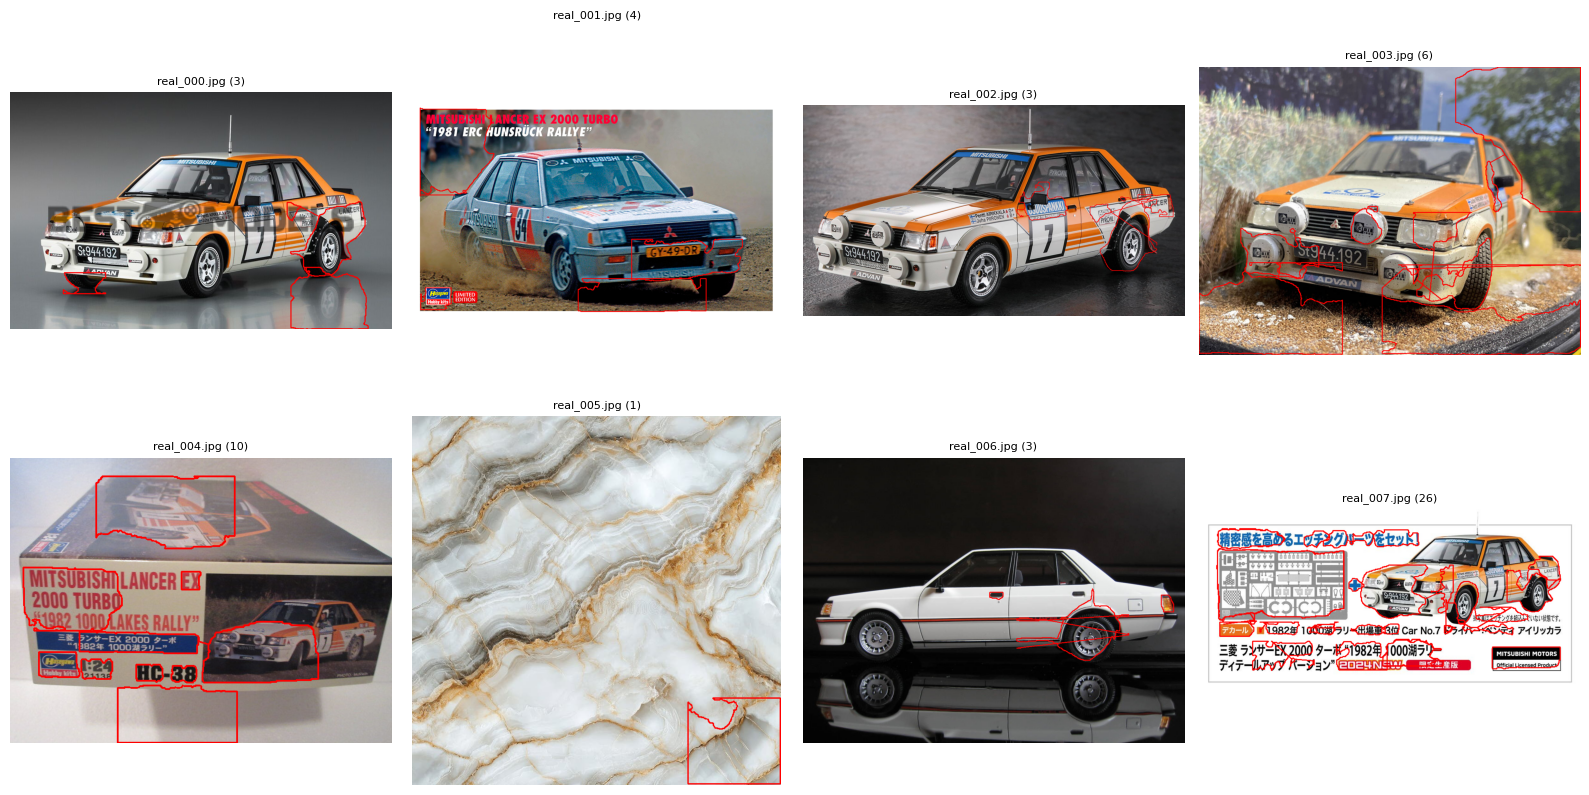

In [13]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def mostrar_auto_labels(carpeta_imgs, carpeta_labels, n=8):
    imgs = sorted(carpeta_imgs.glob("*.*"))[:n]
    fig, axs = plt.subplots(2, 4, figsize=(16, 8))
    for ax, img_path in zip(axs.flat, imgs):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl_path = carpeta_labels / (img_path.stem + ".txt")
        n_instancias = 0
        if lbl_path.exists():
            for linea in lbl_path.read_text().splitlines():
                if not linea.strip():
                    continue
                vals = linea.split()
                pts = [(float(vals[i]) * w, float(vals[i + 1]) * h) for i in range(1, len(vals), 2)]
                pts = np.array(pts, dtype=np.int32)
                cv2.polylines(img, [pts], True, (255, 0, 0), 2)
                n_instancias += 1
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{img_path.name} ({n_instancias})", fontsize=8)
    plt.tight_layout()
    plt.show()

mostrar_auto_labels(REAL_DIR, LABELS_REAL_DIR, n=8)
# corre esta celda de nuevo cambiando el slicing [8:16], [16:24]... para ver el resto

**Revision manual:** borra (imagen + su `.txt`) las fotos donde el auto-label
quedo claramente mal (no detecto nada teniendo moscas visibles, o el poligono
esta pegado a otra cosa). No necesitas que la clase este perfecta — para el
objetivo de conteo, lo que importa es que el poligono SI marque cada mosca.

## 8. Split train/val/test + fusion con el dataset sintetico + actualizar `data.yaml`

In [14]:
import random

reales_ok = [p for p in REAL_DIR.glob("*.*") if (LABELS_REAL_DIR / (p.stem + ".txt")).exists()
             and (LABELS_REAL_DIR / (p.stem + ".txt")).read_text().strip()]
random.seed(42)
random.shuffle(reales_ok)

n = len(reales_ok)
n_train, n_val = int(n * 0.6), int(n * 0.2)
splits = {
    "train": reales_ok[:n_train],
    "val": reales_ok[n_train:n_train + n_val],
    "test": reales_ok[n_train + n_val:],
}

for split_name, archivos in splits.items():
    destino = SYN_DIR / split_name
    (destino / "images").mkdir(parents=True, exist_ok=True)
    (destino / "labels").mkdir(parents=True, exist_ok=True)
    for img_path in archivos:
        shutil.copy(img_path, destino / "images" / img_path.name)
        shutil.copy(LABELS_REAL_DIR / (img_path.stem + ".txt"), destino / "labels" / (img_path.stem + ".txt"))
    print(f"{split_name}: {len(archivos)} fotos reales agregadas")

data_yaml_path = SYN_DIR / "data.yaml"
contenido = data_yaml_path.read_text()
if "test:" not in contenido:
    contenido += "test: test/images\n"
    data_yaml_path.write_text(contenido)
print(data_yaml_path.read_text())

# guarda la lista de imagenes reales de test para la evaluacion de conteo del paso 10
REAL_TEST_IMAGES = [SYN_DIR / "test" / "images" / p.name for p in splits["test"]]
print("Imagenes reales de test:", [p.name for p in REAL_TEST_IMAGES])

train: 43 fotos reales agregadas
val: 14 fotos reales agregadas
test: 16 fotos reales agregadas
path: /content/dataset-moscas/synthetic
train: train/images
val: val/images

nc: 5
names: ['Muscidae', 'Calliphoridae', 'Sarcophagidae', 'Drosophilidae', 'Stratiomyidae']
test: test/images

Imagenes reales de test: ['real_004.jpg', 'real_042.jpg', 'real_000.jpg', 'real_051.jpg', 'real_069.jpg', 'real_036.jpg', 'real_013.jpg', 'real_035.jpg', 'real_040.jpg', 'real_033.jpg', 'real_047.jpg', 'real_061.jpg', 'real_080.jpg', 'real_088.jpg', 'real_089.jpg', 'real_018.jpg']


## 9. Fine-tuning (parte de `best.pt`, pocas epocas, LR bajo)
`freeze=10` congela las primeras 10 capas (backbone) para no perder lo ya
aprendido de forma general con el sintetico; solo las capas mas cercanas a la
salida se ajustan fuerte al dominio real. Si tienes pocas fotos reales (que es
tu caso), esto reduce el riesgo de que el modelo "olvide" el sintetico.

In [ ]:
modelo_finetune = YOLO(BEST_WEIGHTS_SINTETICO)

resultados_ft = modelo_finetune.train(
    task="segment",
    data=str(SYN_DIR / "data.yaml"),
    epochs=20,
    imgsz=640,
    batch=16,
    lr0=0.001,
    freeze=10,
    name="moscas_finetune_real",
)

BEST_WEIGHTS_FINETUNE = resultados_ft.save_dir / "weights" / "best.pt"
print("Nuevo modelo fine-tuned en:", BEST_WEIGHTS_FINETUNE)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset-moscas/synthetic/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/segment/moscas_piloto_seg-4/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

## 10. Metricas oficiales de referencia (mAP por clase)
Estas metricas siguen usando la clase predicha, que no esta verificada en las
fotos reales — sirven solo como referencia, no como criterio principal de
exito.

In [ ]:
modelo_eval = YOLO(str(BEST_WEIGHTS_FINETUNE))
metrics = modelo_eval.val(data=str(SYN_DIR / "data.yaml"), split="test", conf=0.3, plots=True)

m = metrics.seg if hasattr(metrics, "seg") else metrics.box
print("mAP50 (mask, test=fotos reales):", m.map50)
print("mAP50-95 (mask, test=fotos reales):", m.map)
print("Precision (mean):", m.mp)
print("Recall (mean):", m.mr)

## 11. La metrica que de verdad importa: conteo de moscas en fotos reales
Cuenta a ojo cuantas moscas hay en cada foto real de `test` (no importa la
especie, solo el numero) y llena el diccionario `conteo_manual` de abajo. Es
rapido: son las mismas fotos que ya viste en la revision visual del paso 7.

In [ ]:
# 1) mira cada imagen de REAL_TEST_IMAGES y anota cuantas moscas cuentas a ojo
for img_path in REAL_TEST_IMAGES:
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [ ]:
# 2) llena esto a mano con tu conteo real por foto (mismo orden que arriba)
conteo_manual = {
    # "real_003.jpg": 7,
    # "real_011.jpg": 4,
}

assert set(conteo_manual.keys()) == {p.name for p in REAL_TEST_IMAGES}, \
    "Falta contar alguna imagen (o sobra una que ya no existe), revisa las llaves"

# 3) conteo del modelo (clase-agnostico: cuenta toda instancia detectada, no importa cual clase)
errores = []
for img_path in REAL_TEST_IMAGES:
    res = modelo_eval.predict(str(img_path), conf=0.3, verbose=False)[0]
    conteo_modelo = len(res.boxes) if res.boxes is not None else 0
    conteo_real = conteo_manual[img_path.name]
    errores.append(abs(conteo_modelo - conteo_real))
    print(f"{img_path.name}: modelo={conteo_modelo}  real={conteo_real}  diff={abs(conteo_modelo - conteo_real)}")

mae = sum(errores) / len(errores)
print(f"\nMAE de conteo (fotos reales): {mae:.2f} moscas por foto")

## Notas finales

- **Por que fine-tuning y no reentrenar desde cero:** el sintetico ya le enseno
  al modelo la forma/silueta general de una mosca sobre fondo amarillo. Partir
  de `best.pt` con pocas epocas y LR bajo adapta el modelo al dominio real sin
  tirar ese aprendizaje, y es mucho mas rapido.
- **Por que la clase (especie) no es el foco aqui:** no hay forma de verificar
  la especie real en fotos bajadas de internet, asi que cualquier metrica de
  precision por especie sobre estas fotos es ruidosa por definicion. El
  `freeze=10` protege lo ya aprendido de especie en el sintetico; el conteo
  MAE del paso 11 es el numero honesto para saber si esto realmente sirve.
- **Si el MAE sale alto:** lo mas probable no es la arquitectura, es que las
  fotos de internet tienen ademas moscas que se superponen mucho o son de
  trampas muy distintas a las tuyas (perspectiva, resolucion). Con fotos
  reales tuyas propias (aunque sean pocas) el fine-tuning mejora bastante mas
  que con fotos genericas de internet — considera agregarlas cuando puedas.